No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[[0.+0.j 2.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [2.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 2.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 2.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 2.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 2.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 2.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 2.+0.j 0.+0.j]]


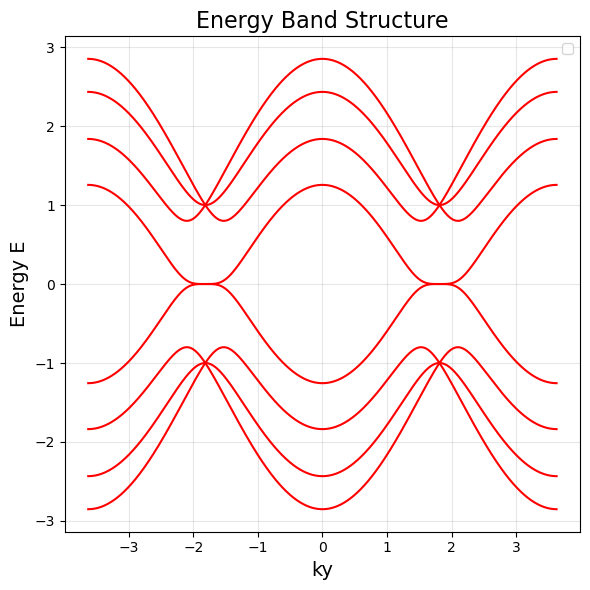

In [205]:
#石墨烯
import numpy as np
import matplotlib.pyplot as plt

# 参数设置
a = 1
t = 1
V = 0
k = 4

def H_func_shi(a ,kx ,t ,k ,V):   
    H_matrix = np.zeros((2*k, 2*k), dtype=complex)
    for i in range(0,2*k,2):
        if i == 0:
            H_matrix[i, i] = V   
            H_matrix[i, i+1] = 2*t*np.cos((3)**0.5*a/2*kx)
            H_matrix[i+1, i] = 2*t*np.cos((3)**0.5*a/2*kx)
            H_matrix[i+1, i+1] = V 
            H_matrix[i, i+3] = t
            #H_matrix[i, i-1] =  t
        elif i == 2*k-2:
            H_matrix[i, i] = V   
            H_matrix[i, i+1] = 2*t*np.cos((3)**0.5*a/2*kx)
            H_matrix[i+1, i] = 2*t*np.cos((3)**0.5*a/2*kx)
            H_matrix[i+1, i+1] = V 
            H_matrix[i+1, i-2] = t 
        else:  
            H_matrix[i, i] = V   
            H_matrix[i, i+1] = 2*t*np.cos((3)**0.5*a/2*kx)
            H_matrix[i+1, i] = 2*t*np.cos((3)**0.5*a/2*kx)
            H_matrix[i+1, i+1] = V
            H_matrix[i, i+3] = t
            H_matrix[i+1, i-2] = t
    return H_matrix
kx=0
print(H_func_shi(a ,kx ,t ,k ,V))

kx_set = np.linspace(-np.pi/((3)**0.5*a/2), np.pi/((3)**0.5*a/2), 1000) 

jueguo = [[] for _ in range(k*2)] 

for kx in kx_set:
    H_matrix = H_func_shi(a ,kx ,t ,k ,V)
    eigenvalues = np.linalg.eigvals(H_matrix)

    eigenvalues_sorted = sorted(eigenvalues, key=lambda x: x.real)
    
    for j in range(2*k):
        jueguo[j].append(eigenvalues_sorted[j].real)  
plt.figure(figsize=(6, 6))

for band_idx in range(2*k):
    plt.plot(kx_set, jueguo[band_idx],color='red') #label=f'Band {band_idx+1}', linewidth=2)
#for band_idx in range(k,2*k):
#    plt.plot(ky_set+0.05, jueguo[band_idx],color='blue',linewidth=1)

plt.xlabel('ky', fontsize=14)
plt.ylabel('Energy E', fontsize=14)
plt.title('Energy Band Structure', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 输出一些信息
#print(f"能带数量: {k}")
#print(f"ky点数: {len(ky_set)}")
#print(f"能量范围: {min(min(band) for band in jueguo):.3f} 到 {max(max(band) for band in jueguo):.3f}")

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def gsr_func(ALR0, T):
    gs1 = np.linalg.inv(ALR0) 
    IC = 0
    while True:
        zineng1 = T.conj().T @ gs1 @ T
        gs2 = np.linalg.inv(ALR0 - zineng1)
        gs1 = 0.5 * gs1 + 0.5 * gs2
        IC += 1
        if IC > 1000:
            break
    return gs1

def G_func(J, k, ALR, T, zinengr,zinengl):
    G_result = np.zeros((J, J, 2*k, 2*k), dtype=complex)

    for i in range(J):
        if i == 0:
            G_result[i, i] = np.linalg.inv(ALR - zinengr)
        
        elif 0 < i <= J-2:
            G_result[i, i] = np.linalg.inv(ALR - T @ G_result[i-1, i-1] @ T)
            G_result[0, i] = G_result[0, i-1] @ T @ G_result[i, i]
        
        elif i == J-1:
            AA = ALR - T.conj().T@ G_result[i-1, i-1] @ T - zinengl
            G_result[i, i] = np.linalg.inv(AA)
            G_result[0, i] = G_result[0, i-1] @ T @ G_result[i, i]
    
    return G_result

def H_func_shi_2(t ,k ,V):   
    H_matrix = np.zeros((2*k, 2*k), dtype=complex)
    for i in range(0,2*k,2):
        if i == 0:
            H_matrix[i, i] = V   
            H_matrix[i, i+1] =0
            H_matrix[i+1, i] = 0
            H_matrix[i+1, i+1] = V 
            H_matrix[i, i+3] = t
            #H_matrix[i, i-1] =  t
        elif i == 2*k-2:
            H_matrix[i, i] = V   
            H_matrix[i, i+1] = 0
            H_matrix[i+1, i] = 0
            H_matrix[i+1, i+1] = V 
            H_matrix[i+1, i-2] = t 
        else:  
            H_matrix[i, i] = V   
            H_matrix[i, i+1] = 0
            H_matrix[i+1, i] =0
            H_matrix[i+1, i+1] = V
            H_matrix[i, i+3] = t
            H_matrix[i+1, i-2] = t
    return H_matrix

def T_fumc_BA(t, k):   
    T_matrix = np.zeros((2*k, 2*k), dtype=complex)
    for i in range(0,2*k,2):
            T_matrix[i, i] = 0  
            T_matrix[i, i+1] =t
            T_matrix[i+1, i] = t
            T_matrix[i+1, i+1] = 0 
    return T_matrix
def T_fumc_AB(t, k):   
    T_matrix = np.zeros((2*k, 2*k), dtype=complex)
    for i in range(0,2*k,2):
            T_matrix[i, i] = 0
            T_matrix[i, i+1] =t
            T_matrix[i+1, i] = t
            T_matrix[i+1, i+1] = 0 
    return T_matrix
def T_fumc(t, k):   
    T_matrix = np.zeros((2*k, 2*k), dtype=complex)
    for i in range(0,2*k,2):
            T_matrix[i, i] = 0
            T_matrix[i, i+1] =t
            T_matrix[i+1, i] = t
            T_matrix[i+1, i+1] = 0 
    return T_matrix

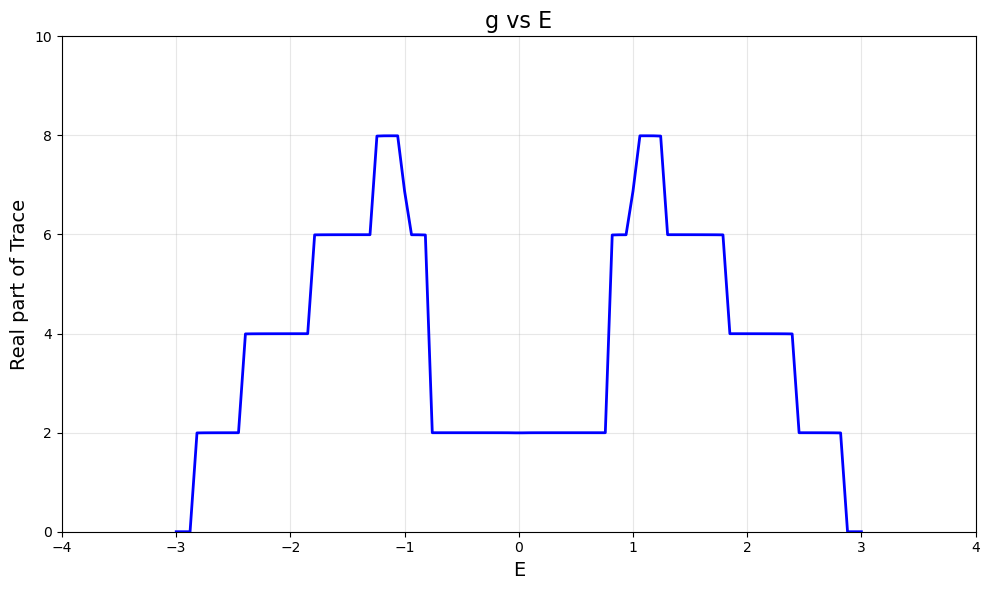

In [244]:
# 参数设置
t = 1
V = 0
k = 4
J =50
NJ = 1e-5

H = H_func_shi_2(t ,k ,V)
#T=T_fumc(t, k)
#TBA=T_fumc_BA(t, k)
#TAB=T_fumc_AB(t, k)
T2=TAB=TBA=T_fumc(t, k)
#T2=T_fumc(t, k)
#TAB=T_fumc_AB(t, k)
#T2=np.eye(2*k)

E_values = np.linspace(-3, 3, 100)  
#E_values=np.linspace(min(eigenvalues),max(eigenvalues),k)
#E_values=sorted(eigenvalues)

trace_real_values = []  

for E in E_values:

    ALR0 = (E + NJ*1j) * np.eye(k*2) - H #+ Vt*np.eye(k)

    ALR = (E + NJ*1j)  * np.eye(k*2) - H 
    

    # 计算表面格林函数
    gsrAB = gsr_func(ALR0, TAB)
    gsrBA = gsr_func(ALR0, TBA)
  
    
    #print(GSR.shape)
    # 计算自能
    #zinengr = t*np.eye(k) @ gsr @ (t*np.eye(k))
    zinengl=  T2.T @ gsrAB @ T2
    zinengr = T2.T @ gsrBA @ T2
    #zinengl=   gsrAB 
    #zinengr =   gsrBA 

    # 计算Γ矩阵
    T11 = 1j * (zinengl - zinengl.conj())

    TNN = 1j * (zinengr - zinengr.conj())
    
    # 计算格林函数
    G = G_func(J, k, ALR, TBA, zinengr,zinengl)
    G1N = G[0, J-1]  # 从第1层到第N层的格林函数
    
    GT = T11 @ G1N @ TNN @ G1N.conj().T
    trace = np.trace(GT)
    
    trace_real_values.append(trace.real)


plt.figure(figsize=(10, 6))
plt.plot(E_values, trace_real_values, 'b-', linewidth=2)
plt.xlabel('E', fontsize=14)
plt.ylabel('Real part of Trace', fontsize=14)
plt.title('g vs E', fontsize=16)
plt.grid(True, alpha=0.3)
plt.xlim(min(E_values)-1, max(E_values)+1)
plt.ylim(0,10)
plt.tight_layout()


#for i in eigenvalues:
#    plt.axvline(x=i,  linestyle='--', alpha=0.7,  linewidth=2)

plt.show()


#print(E_values)
#print(trace_real_values)

[[0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]]


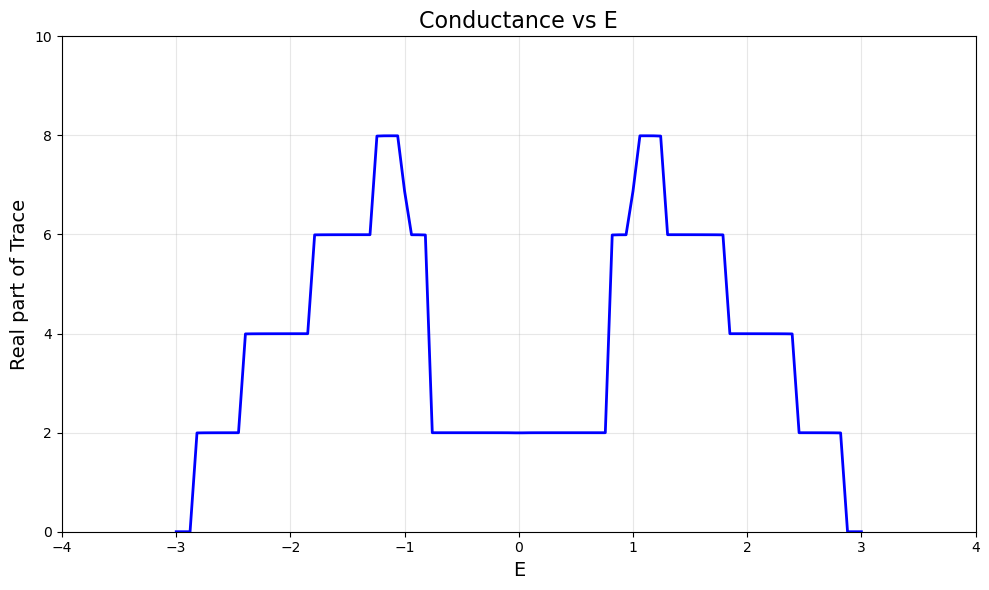

In [225]:
import numpy as np
import matplotlib.pyplot as plt

def gsr_func(ALR0, T):
    # 使用 Dyson 方程计算表面格林函数
    gs1 = np.linalg.inv(ALR0)
    max_iter = 1000
    tolerance = 1e-6
    IC = 0
    
    while True:
        zineng1 = T.conj().T @ gs1 @ T  # 计算自能
        gs2 = np.linalg.inv(ALR0 - zineng1)  # 更新格林函数
        gs1 = 0.5 * gs1 + 0.5 * gs2  # 平均迭代
        IC += 1
        if np.linalg.norm(gs2 - gs1) < tolerance or IC > max_iter:
            break
    return gs1

def G_func(J, k, ALR, T, zinengr, zinengl):
    # 计算格林函数
    G_result = np.zeros((J, J, 2*k, 2*k), dtype=complex)

    for i in range(J):
        if i == 0:
            G_result[i, i] = np.linalg.inv(ALR - zinengr)  # 计算第一层格林函数
        elif 0 < i <= J-2:
            G_result[i, i] = np.linalg.inv(ALR - T.conj().T @ G_result[i-1, i-1] @ T)  # 递归计算
            G_result[0, i] = G_result[0, i-1] @ T @ G_result[i, i]  # 更新
        elif i == J-1:
            AA = ALR - T.conj().T @ G_result[i-1, i-1] @ T - zinengl
            G_result[i, i] = np.linalg.inv(AA)
            G_result[0, i] = G_result[0, i-1] @ T @ G_result[i, i]
    
    return G_result

def H_func_shi_2(t ,k ,V):   
    # 构造哈密顿量矩阵
    H_matrix = np.zeros((2*k, 2*k), dtype=complex)
    for i in range(0, 2*k, 2):
        if i == 0:
            H_matrix[i, i] = V
            H_matrix[i, i+1] = 0
            H_matrix[i+1, i] = 0
            H_matrix[i+1, i+1] = V 
            H_matrix[i, i+3] = t
        elif i == 2*k-2:
            H_matrix[i, i] = V   
            H_matrix[i, i+1] = 0
            H_matrix[i+1, i] = 0
            H_matrix[i+1, i+1] = V 
            H_matrix[i+1, i-2] = t 
        else:  
            H_matrix[i, i] = V   
            H_matrix[i, i+1] = 0
            H_matrix[i+1, i] = 0
            H_matrix[i+1, i+1] = V
            H_matrix[i, i+3] = t
            H_matrix[i+1, i-2] = t
    return H_matrix

def T_fumc(t, k):   
    # 构造 T 矩阵
    T_matrix = np.zeros((2*k, 2*k), dtype=complex)
    for i in range(0, 2*k, 2):
        T_matrix[i, i] = 0
        T_matrix[i, i+1] = t
        T_matrix[i+1, i] = t
        T_matrix[i+1, i+1] = 0 
    return T_matrix

# 参数设置
t = 1
V = 0
k = 4
J = 50
NJ = 1e-5

H = H_func_shi_2(t, k, V)
print(H)
T2 = T_fumc(t, k)

E_values = np.linspace(-3, 3, 100)
trace_real_values = []

for E in E_values:
    ALR0 = (E + NJ*1j) * np.eye(k*2) - H
    ALR = (E + NJ*1j) * np.eye(k*2) - H

    # 计算表面格林函数
    gsrAB = gsr_func(ALR0, T2)
    gsrBA = gsr_func(ALR0, T2)

    # 计算自能
    zinengl = T2.T @ gsrAB @ T2
    zinengr = T2.T @ gsrBA @ T2

    # 计算Γ矩阵
    T11 = 1j * (zinengl - zinengl.conj())
    TNN = 1j * (zinengr - zinengr.conj())

    # 计算格林函数
    G = G_func(J, k, ALR, T2, zinengr, zinengl)
    G1N = G[0, J-1]  # 从第1层到第N层的格林函数

    GT = T11 @ G1N @ TNN @ G1N.conj().T
    trace = np.trace(GT)

    # 计算电导
    trace_real_values.append(trace.real)

# 绘制结果
plt.figure(figsize=(10, 6))
plt.plot(E_values, trace_real_values, 'b-', linewidth=2)
plt.xlabel('E', fontsize=14)
plt.ylabel('Real part of Trace', fontsize=14)
plt.title('Conductance vs E', fontsize=16)
plt.grid(True, alpha=0.3)
plt.xlim(min(E_values)-1, max(E_values)+1)
plt.ylim(0, 10)
plt.tight_layout()
plt.show()
